# Village-Level Water Quality Analysis

This notebook replicates the water quality analysis from `water_quality_analysis.ipynb`, but aggregated at the **village level** rather than the pond level.

Steps:
1. Infer village names for ponds using coordinate proximity (Haversine distance).
2. Merge with water quality data.
3. Aggregate measurements by `inferred_village` and `Date` to handle multiple pond measurements in a single village on the same day.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, cos, sin, asin, sqrt

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return 2 * 6371 * asin(sqrt(a))

# Load Datasets
df_wq = pd.read_csv('data/water_quality.csv')
df_loc = pd.read_csv('data/Shared_ 2026 Github ARA Pond IDs Key.csv')

# Clean Location Data
df_loc_clean = df_loc[['public_pond_id', 'region', 'village', 'latitude', 'longitude']].copy()
df_loc_clean['latitude'] = pd.to_numeric(df_loc_clean['latitude'], errors='coerce')
df_loc_clean['longitude'] = pd.to_numeric(df_loc_clean['longitude'], errors='coerce')
df_loc_clean['has_coords'] = df_loc_clean['latitude'].notna() & df_loc_clean['longitude'].notna()
df_loc_clean['has_village'] = df_loc_clean['village'].notna() & df_loc_clean['village'].astype(str).str.strip().ne('')

# Reference ponds (with village and coords)
ref_ponds = df_loc_clean[df_loc_clean['has_coords'] & df_loc_clean['has_village']].copy()

def infer_village(row):
    if row['has_village']:
        return row['village']
    if not row['has_coords']:
        return None
    
    min_dist = float('inf')
    best_village = None
    
    for _, ref in ref_ponds.iterrows():
        d = haversine_km(row['latitude'], row['longitude'], ref['latitude'], ref['longitude'])
        if d < min_dist:
            min_dist = d
            best_village = ref['village']
    return best_village

df_loc_clean['inferred_village'] = df_loc_clean.apply(infer_village, axis=1)
df_loc_clean['location_status'] = df_loc_clean.apply(
    lambda r: 'Has Location' if (r['has_coords'] or r['has_village']) else 'No Location', axis=1
)

# Rename columns in WQ data to standard names
df_wq = df_wq.rename(columns={
    'Date of data collection': 'Date',
    'Time of data collection': 'Time',
    'DO (mg/L)': 'DO',
    'Temp (in °C)': 'Water Temperature'
})
df_wq['Date'] = pd.to_datetime(df_wq['Date'])

# Merge WQ with Inferred Locations
df_merged = df_wq.merge(df_loc_clean[['public_pond_id', 'inferred_village', 'location_status', 'region']], 
                        left_on='pond_id', right_on='public_pond_id', how='left')

# Filter for ponds with location
df_clean = df_merged[df_merged['location_status'] == 'Has Location'].drop(columns=['public_pond_id', 'location_status'])

print(f"Total observations with location (known or inferred): {len(df_clean)}")

Total observations with location (known or inferred): 9932


## Data Aggregation to Village Level

We aggregate pond-level measurements into a single village-level daily summary. This accounts for multiple ponds being measured in the same village on the same day.

In [10]:
# Aggregation logic
df_village = df_clean.groupby(['inferred_village', 'Date', 'Type']).agg(
    n_ponds=('pond_id', 'nunique'),
    highest_DO=('DO', 'max'),
    lowest_DO=('DO', 'min'),
    median_DO=('DO', 'median'),
    low_quartile_DO=('DO', lambda x: x.quantile(0.25)),
    high_quartile_DO=('DO', lambda x: x.quantile(0.75)),
    average_DO=('DO', 'mean'),
    # Also keep pH and Temperature averages for completeness if needed
    average_pH=('pH', 'mean'),
    average_temp=('Water Temperature', 'mean')
).reset_index()

df_village.head()

,inferred_village,Date,Type,n_ponds,highest_DO,lowest_DO,median_DO,low_quartile_DO,high_quartile_DO,average_DO,average_pH,average_temp
0,Aamuluru,2023-09-12,Evening,5,10.3,8.6,8.8,8.8,9.1,9.12,8.240,30.76
1,Aamuluru,2023-09-12,Morning,5,4.1,3.3,3.5,3.4,3.8,3.62,8.040,29.28
2,Aamuluru,2023-10-12,Evening,5,10.5,7.3,9.1,9.1,9.6,9.12,8.426,32.60
3,Aamuluru,2023-10-12,Morning,5,4.2,2.1,3.8,3.3,3.9,3.46,8.256,31.50
4,Aamuluru,2023-10-14,Evening,1,7.3,7.3,7.3,7.3,7.3,7.30,8.400,32.90


## Analysis 1 — Water Quality Descriptive Statistics (Village Level)

Note: We use the `average_DO` of the village for the general stats.

In [ ]:
stats_cols = ['average_DO', 'average_pH', 'average_temp']
df_village[stats_cols].describe().round(2)

## Analysis 2 — Frequency of Measurements (Village Level)

This section analyses **how often villages are measured** using only `Type == "Morning"` observations. 
Any sampling from a pond within a village counts as a measurement for that village.

In [11]:
# Filter for Morning only as in the original analysis
morning_village = df_village[df_village['Type'].str.lower() == 'morning'].copy()
morning_village = morning_village.sort_values(['inferred_village', 'Date'])

# Calculate gaps between measurements for each village
morning_village['gap_days'] = morning_village.groupby('inferred_village')['Date'].diff().dt.days

gaps = morning_village.dropna(subset=['gap_days']).copy()

print(f"Morning observations (village-days) : {len(morning_village):,}")
print(f"Unique villages                     : {morning_village['inferred_village'].nunique():,}")
print(f"\nInter-measurement gap summary (days):")
print(gaps['gap_days'].describe().round(1))

Morning observations (village-days) : 2,318
Unique villages                     : 22

Inter-measurement gap summary (days):
count    2296.0
mean        9.0
std        13.2
min         1.0
25%         2.0
50%         5.0
75%        12.0
max       312.0
Name: gap_days, dtype: float64


In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(gaps['gap_days'], bins=50, kde=True)
plt.title('Distribution of Gaps Between Village Measurements (Morning Only)')
plt.xlabel('Days Between Successive Village Measurements')
plt.ylabel('Frequency')
plt.show()

## Analysis 3 — Total Observations per Village

We calculate how many morning measurement days each village has accumulated.

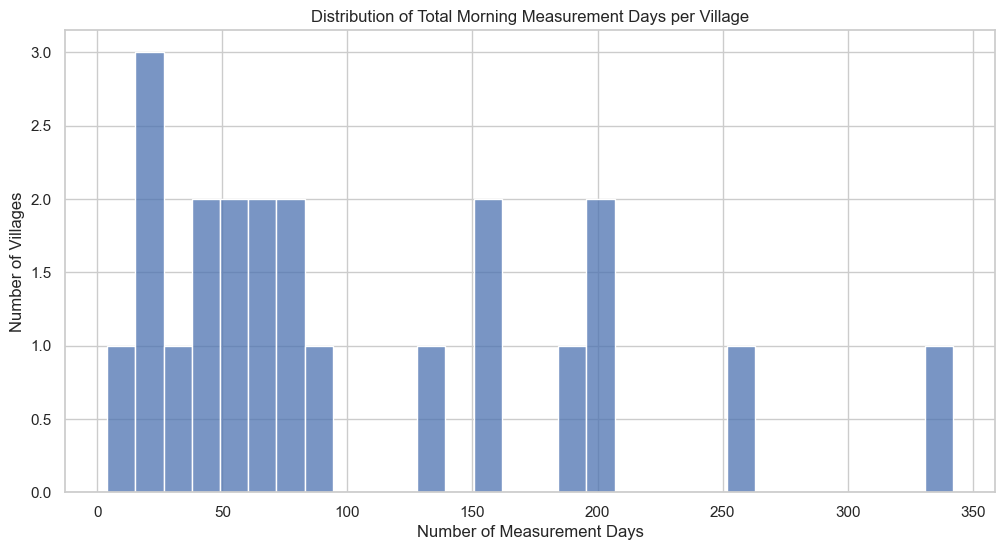

Top 10 villages by measurement frequency:
inferred_village
Sreeparru         342
Komarika          253
Ponangi           204
Maanuru           196
Jalipudi          194
Indukurpeta       160
Somarajupalli     158
Durgapuram        133
Pathamupparu       84
Veeramma Kunta     81
dtype: int64


In [12]:
village_counts = morning_village.groupby('inferred_village').size().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.histplot(village_counts, bins=30)
plt.title('Distribution of Total Morning Measurement Days per Village')
plt.xlabel('Number of Measurement Days')
plt.ylabel('Number of Villages')
plt.show()

print("Top 10 villages by measurement frequency:")
print(village_counts.head(10))

## Analysis 4 — Dissolved Oxygen Levels across Regions

We compare DO levels across regions using the village-level average DO.

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='region', y='average_DO', data=morning_village, hue='region', palette='Set2', legend=False)
plt.title('Dissolved Oxygen Levels across Regions (Village-Day Averages)')
plt.ylabel('Average DO (mg/L)')
plt.show()

ValueError: Could not interpret value `region` for `x`. An entry with this name does not appear in `data`.

<Figure size 1200x600 with 0 Axes>

## Analysis 5 — Monthly Observation Trends (Village Level)

We examine how active sampling has been across months at the village level.

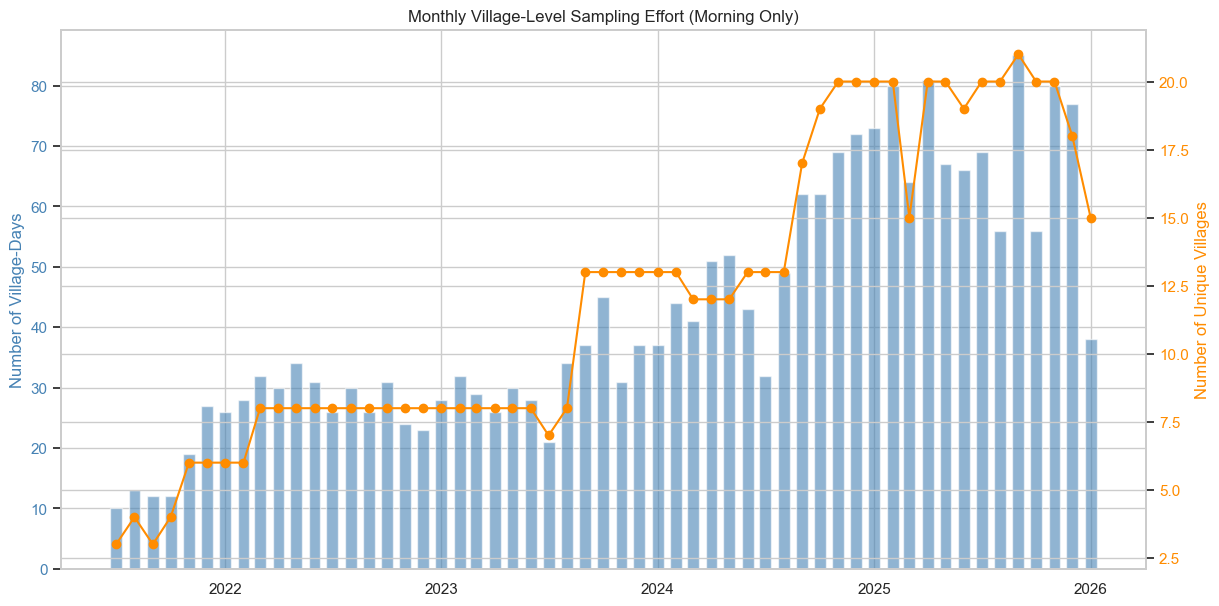

In [14]:
morning_village['Month'] = morning_village['Date'].dt.to_period('M')
monthly_stats = morning_village.groupby('Month').agg(
    total_village_days=('inferred_village', 'count'),
    unique_villages=('inferred_village', 'nunique')
).reset_index()
monthly_stats['Month_Timestamp'] = monthly_stats['Month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 7))

ax1.bar(monthly_stats['Month_Timestamp'], monthly_stats['total_village_days'], width=20, alpha=0.6, label='Total Village-Days sampled', color='steelblue')
ax1.set_ylabel('Number of Village-Days', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly_stats['Month_Timestamp'], monthly_stats['unique_villages'], color='darkorange', marker='o', label='Unique Villages sampled')
ax2.set_ylabel('Number of Unique Villages', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Monthly Village-Level Sampling Effort (Morning Only)')
plt.show()

## Analysis 6 — Within-Village DO Variance

Since some villages have multiple ponds sampled on the same day, we look at the difference between the `highest_DO` and `lowest_DO` recorded in a village on a single morning.

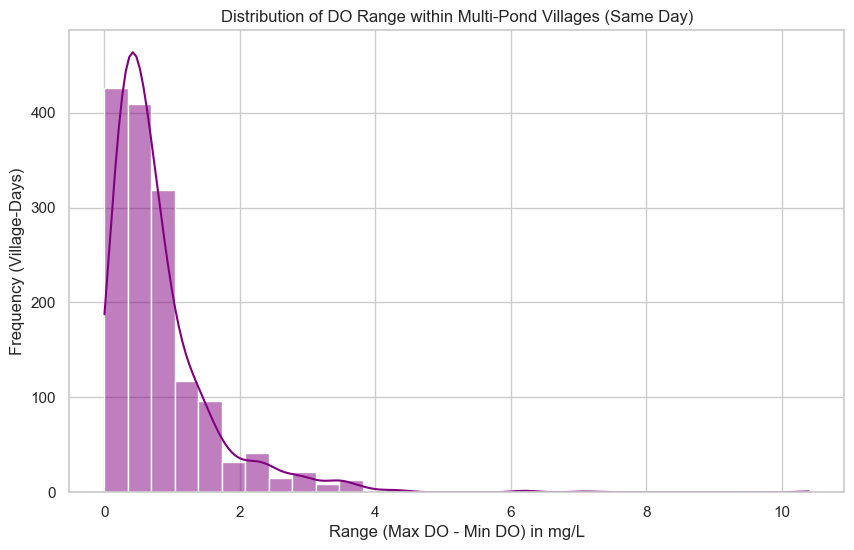

Average DO variation across ponds in the same village: 0.81 mg/L


In [15]:
multi_pond_days = morning_village[morning_village['n_ponds'] > 1].copy()
multi_pond_days['do_range'] = multi_pond_days['highest_DO'] - multi_pond_days['lowest_DO']

plt.figure(figsize=(10, 6))
sns.histplot(multi_pond_days['do_range'].dropna(), bins=30, kde=True, color='purple')
plt.title('Distribution of DO Range within Multi-Pond Villages (Same Day)')
plt.xlabel('Range (Max DO - Min DO) in mg/L')
plt.ylabel('Frequency (Village-Days)')
plt.show()

print(f"Average DO variation across ponds in the same village: {multi_pond_days['do_range'].mean():.2f} mg/L")

## Analysis 7 — Village-Level Retention Rate

We examine Month-over-Month retention: the percentage of villages measured in month M that are also measured in month M+1.

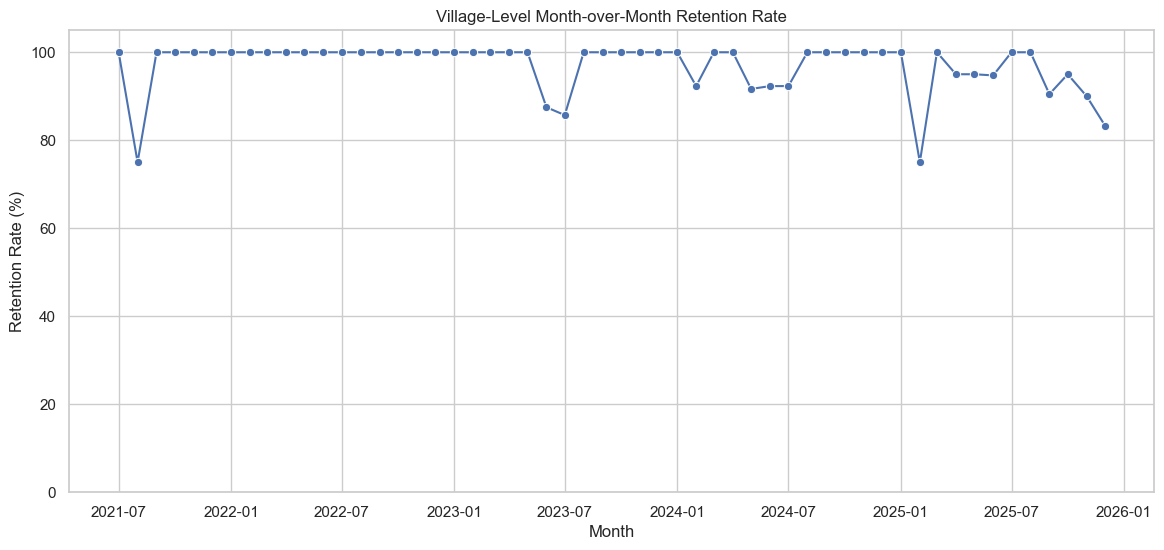

In [16]:
v_months = morning_village.groupby('Month')['inferred_village'].apply(set).to_dict()
sorted_months = sorted(v_months.keys())

retention_rows = []
for i in range(len(sorted_months) - 1):
    m0, m1 = sorted_months[i], sorted_months[i+1]
    s0, s1 = v_months[m0], v_months[m1]
    
    if (m1 - m0).n == 1: # consecutive months
        retained = len(s0 & s1)
        retention_rate = retained / len(s0)
        retention_rows.append({
            'Month': m0.to_timestamp(),
            'Retention Rate (%)': retention_rate * 100
        })

ret_df = pd.DataFrame(retention_rows)

plt.figure(figsize=(14, 6))
sns.lineplot(x='Month', y='Retention Rate (%)', data=ret_df, marker='o')
plt.title('Village-Level Month-over-Month Retention Rate')
plt.ylim(0, 105)
plt.show()

## Analysis 8 — Variance Decomposition: Between-Day vs Between-Village (within Day) vs Within-Village-Day

We decompose the total DO variance into three hierarchical components using the nesting **Ponds ⊂ Village-Days ⊂ Days**, separately **per region**:

| Component | Description |
|---|---|
| **Between-Day** | How much the daily grand-mean DO fluctuates from day to day |
| **Between-Village (within Day)** | Conditional on the day, how much do village means differ from the day's grand mean |
| **Within-Village-Day** | How much individual pond readings vary within the same village on the same day |

Three statistically grounded approaches are used:
1. **Hierarchical Sum-of-Squares Decomposition** — exact, additive partition of total SS under the nesting Days > Villages-within-Days > Ponds.
2. **Mixed-Effects Variance Components** — REML estimates of σ²_day, σ²_village|day, σ²_within from a single model with day random intercept and village variance component.
3. **Sequential (Type I) F-tests** — Day entered first, Village entered second; the sequential SS are additive and match the SS decomposition, with F-tests for each stratum.

In [8]:
# Prepare pond-level morning data for variance decomposition
morning_ponds = df_clean[df_clean['Type'].str.lower() == 'morning'].copy()

# Handle region column naming (merge may produce region_x / region_y)
if 'region' not in morning_ponds.columns:
    region_col = 'region_y' if 'region_y' in morning_ponds.columns else 'region_x'
    morning_ponds['region'] = morning_ponds[region_col]

morning_ponds = morning_ponds.dropna(subset=['DO', 'inferred_village', 'region'])
morning_ponds['Date_str'] = morning_ponds['Date'].astype(str)

regions = sorted(morning_ponds['region'].dropna().unique())
print(f"Regions: {regions}")
print(f"Total morning pond-level observations with DO: {len(morning_ponds):,}\n")
for r in regions:
    rd = morning_ponds[morning_ponds['region'] == r]
    n_vd_cells = rd.groupby(['inferred_village', 'Date']).ngroups
    n_multi = (rd.groupby(['inferred_village', 'Date']).size() > 1).sum()
    print(f"  {r}: {len(rd):,} obs | {rd['inferred_village'].nunique()} villages | "
          f"{rd['Date'].nunique()} days | {n_vd_cells} village-day cells | "
          f"{n_multi} with >1 pond")

Regions: ['Eluru', 'Nellore']
Total morning pond-level observations with DO: 5,130

  Eluru: 3,469 obs | 15 villages | 781 days | 1569 village-day cells | 998 with >1 pond
  Nellore: 1,661 obs | 7 villages | 652 days | 744 village-day cells | 506 with >1 pond


### Approach 1 — Hierarchical Sum-of-Squares Decomposition

Partition total SS into three additive, exhaustive components using the nested structure
**Ponds ⊂ Village-Days ⊂ Days**:

$$SS_{\text{total}} = SS_{\text{day}} + SS_{\text{village|day}} + SS_{\text{within}}$$

- $SS_{\text{day}} = \sum_j n_{j\cdot} (\bar y_{\cdot j \cdot} - \bar y_{\cdots})^2$
- $SS_{\text{village|day}} = \sum_{i,j} n_{ij} (\bar y_{ij\cdot} - \bar y_{\cdot j \cdot})^2$
- $SS_{\text{within}} = \sum_{i,j,k} (y_{ijk} - \bar y_{ij\cdot})^2$

In [9]:
ss_results = []

for region in regions:
    rdata = morning_ponds[morning_ponds['region'] == region]
    do_vals = rdata['DO'].values
    grand_mean = do_vals.mean()
    ss_total = ((do_vals - grand_mean) ** 2).sum()

    # SS between days: weighted sum of (day_mean - grand_mean)²
    d_stats = rdata.groupby('Date')['DO'].agg(['mean', 'count'])
    ss_day = (d_stats['count'] * (d_stats['mean'] - grand_mean) ** 2).sum()

    # SS between villages within days: weighted sum of (village_day_mean - day_mean)²
    vd_stats = rdata.groupby(['inferred_village', 'Date'])['DO'].agg(['mean', 'count']).reset_index()
    vd_stats = vd_stats.merge(
        d_stats[['mean']].rename(columns={'mean': 'd_mean'}),
        left_on='Date', right_index=True
    )
    ss_village_day = (vd_stats['count'] * (vd_stats['mean'] - vd_stats['d_mean']) ** 2).sum()

    # SS within village-days (residual)
    ss_within = ss_total - ss_day - ss_village_day

    ss_results.append({
        'Region': region,
        '% Between-Day': ss_day / ss_total * 100,
        '% Village|Day': ss_village_day / ss_total * 100,
        '% Within-Village-Day': ss_within / ss_total * 100,
    })

ss_df = pd.DataFrame(ss_results)
print("Approach 1: Hierarchical SS Decomposition  (Days > Villages-within-Days > Ponds)")
print("=" * 90)
display(ss_df.set_index('Region').round(1))

Approach 1: Hierarchical SS Decomposition  (Days > Villages-within-Days > Ponds)


,% Between-Day,% Village|Day,% Within-Village-Day
Region,,,
Eluru,49.3,21.3,29.4
Nellore,57.5,3.0,39.5


### Approach 2 — Mixed-Effects Variance Components (REML)

We fit a single model per region with **Day** as a random-intercept grouping factor and **Village** as a variance component nested within days:

$$y_{ijk} = \mu + u_j + v_{ij} + \varepsilon_{ijk}$$

where $u_j \sim N(0, \sigma^2_{\text{day}})$, $v_{ij} \sim N(0, \sigma^2_{\text{village|day}})$, $\varepsilon_{ijk} \sim N(0, \sigma^2_{\text{within}})$.

The proportion of total variance attributable to each component is reported.

In [11]:
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

vc_results = []

for region in regions:
    rdata = morning_ponds[morning_ponds['region'] == region].copy()

    # Model: random intercept for Date + variance component for Village
    fit = smf.mixedlm(
        "DO ~ 1", data=rdata, groups="Date_str",
        re_formula="1",
        vc_formula={"village": "0 + C(inferred_village)"}
    ).fit(reml=True)

    var_day = float(fit.cov_re.iloc[0, 0])       # Day random intercept
    var_village = float(fit.vcomp[0])              # Village variance component
    var_within = float(fit.scale)                  # Residual
    var_total = var_day + var_village + var_within

    vc_results.append({
        'Region': region,
        'σ²_day': var_day,
        'σ²_village|day': var_village,
        'σ²_within': var_within,
        '% Day': var_day / var_total * 100,
        '% Village|Day': var_village / var_total * 100,
        '% Within': var_within / var_total * 100,
    })

vc_df = pd.DataFrame(vc_results)
print("Approach 2: Variance Components from Mixed-Effects Model (REML)")
print("Model: DO ~ 1 + (1|Date) + vc(Village)")
print("=" * 90)
display(vc_df.set_index('Region').round(3))

Approach 2: Variance Components from Mixed-Effects Model (REML)
Model: DO ~ 1 + (1|Date) + vc(Village)


,σ²_day,σ²_village|day,σ²_within,% Day,% Village|Day,% Within
Region,,,,,,
Eluru,0.176,0.211,0.411,22.061,26.458,51.482
Nellore,0.159,0.000,0.381,29.430,0.000,70.570


### Approach 3 — Sequential (Type I) F-tests

We compute **Type I (sequential) sums of squares** from a two-factor model with Day entered first and Village entered second. Because Type I SS are order-dependent and additive:

$$SS_{\text{total}} = SS_{\text{Day}} + SS_{\text{Village | Day}} + SS_{\text{residual}}$$

This exactly matches the SS decomposition in Approach 1, but now we also obtain **F-statistics** and **p-values** for each stratum, with appropriate degrees of freedom:

- $F_{\text{Day}} = \frac{SS_{\text{Day}} / df_{\text{Day}}}{MS_{\text{within}}}$ ,  $df_{\text{Day}} = J - 1$
- $F_{\text{Village|Day}} = \frac{SS_{\text{Village|Day}} / df_{\text{Village|Day}}}{MS_{\text{within}}}$ ,  $df_{\text{Village|Day}} = (\text{village-day cells}) - J$
- $\eta^2_{\text{partial}}$ gives the proportion of non-day variance explained by village.

In [12]:
from scipy.stats import f as f_dist

ftest_results = []

for region in regions:
    rdata = morning_ponds[morning_ponds['region'] == region]
    do_vals = rdata['DO'].values
    N = len(do_vals)
    grand_mean = do_vals.mean()
    ss_total = ((do_vals - grand_mean) ** 2).sum()

    # Day statistics
    d_stats = rdata.groupby('Date')['DO'].agg(['mean', 'count'])
    J = len(d_stats)  # number of days
    ss_day = (d_stats['count'] * (d_stats['mean'] - grand_mean) ** 2).sum()

    # Village-within-day statistics
    vd_stats = rdata.groupby(['inferred_village', 'Date'])['DO'].agg(['mean', 'count']).reset_index()
    K = len(vd_stats)  # number of village-day cells
    vd_stats = vd_stats.merge(
        d_stats[['mean']].rename(columns={'mean': 'd_mean'}),
        left_on='Date', right_index=True
    )
    ss_village_day = (vd_stats['count'] * (vd_stats['mean'] - vd_stats['d_mean']) ** 2).sum()

    # Residual
    ss_within = ss_total - ss_day - ss_village_day

    # Degrees of freedom
    df_day = J - 1
    df_village_day = K - J   # village-day cells minus days
    df_within = N - K        # obs minus village-day cells

    # Mean squares and F-tests
    ms_day = ss_day / df_day
    ms_village_day = ss_village_day / max(df_village_day, 1)
    ms_within = ss_within / df_within

    f_day = ms_day / ms_within
    f_vd = ms_village_day / ms_within

    p_day = 1 - f_dist.cdf(f_day, df_day, df_within)
    p_vd = 1 - f_dist.cdf(f_vd, df_village_day, df_within)

    # Eta-squared (sequential) and partial eta-squared
    eta2_day = ss_day / ss_total
    eta2_vd = ss_village_day / ss_total
    partial_eta2_vd = ss_village_day / (ss_village_day + ss_within)  # village share of non-day variance

    ftest_results.append({
        'Region': region,
        'η²_day': eta2_day,
        'F_day': f_day,
        'df_day': df_day,
        'p_day': p_day,
        'η²_village|day': eta2_vd,
        'partial_η²_village|day': partial_eta2_vd,
        'F_village|day': f_vd,
        'df_village|day': df_village_day,
        'p_village|day': p_vd,
    })

ftest_df = pd.DataFrame(ftest_results)
print("Approach 3: Sequential (Type I) F-tests  (Day first, then Village|Day)")
print("=" * 90)
display(ftest_df.set_index('Region').round(4))

Approach 3: Sequential (Type I) F-tests  (Day first, then Village|Day)


,η²_day,F_day,df_day,p_day,η²_village|day,partial_η²_village|day,F_village|day,df_village|day,p_village|day
Region,,,,,,,,,
Eluru,0.4927,4.0782,780,0.0,0.2130,0.4199,1.7450,788,0.0000
Nellore,0.5752,2.0518,651,0.0,0.0299,0.0705,0.7559,92,0.9553


### Summary Visualisation

Comparing the three approaches side by side. All use the same nesting: **Days > Villages-within-Days > Ponds**.

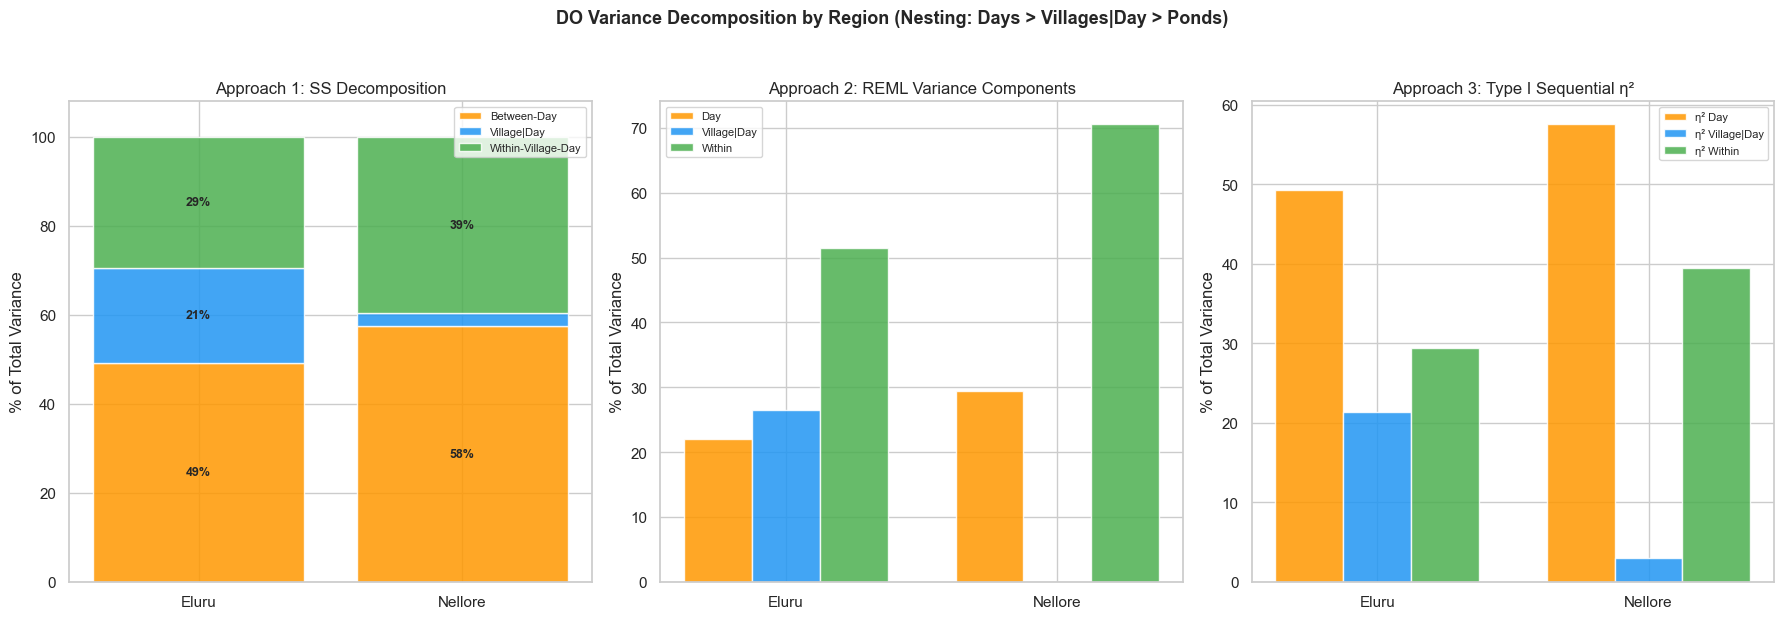

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['#FF9800', '#2196F3', '#4CAF50']

# --- Plot 1: SS Decomposition (stacked bar) ---
ax = axes[0]
bottom = np.zeros(len(ss_df))
for col, color, label in zip(
    ['% Between-Day', '% Village|Day', '% Within-Village-Day'],
    colors,
    ['Between-Day', 'Village|Day', 'Within-Village-Day']
):
    vals = ss_df[col].values
    ax.bar(ss_df['Region'], vals, bottom=bottom, label=label, color=color, alpha=0.85)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            ax.text(i, b + v / 2, f'{v:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold')
    bottom += vals
ax.set_ylabel('% of Total Variance')
ax.set_title('Approach 1: SS Decomposition')
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0, 108)

# --- Plot 2: Variance Components from mixed model ---
ax = axes[1]
x = np.arange(len(vc_df))
w = 0.25
ax.bar(x - w, vc_df['% Day'], w, label='Day', color=colors[0], alpha=0.85)
ax.bar(x,     vc_df['% Village|Day'], w, label='Village|Day', color=colors[1], alpha=0.85)
ax.bar(x + w, vc_df['% Within'], w, label='Within', color=colors[2], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(vc_df['Region'])
ax.set_ylabel('% of Total Variance')
ax.set_title('Approach 2: REML Variance Components')
ax.legend(fontsize=8)

# --- Plot 3: Sequential η² from Type I F-tests ---
ax = axes[2]
eta_within = 1 - ftest_df['η²_day'].values - ftest_df['η²_village|day'].values
ax.bar(x - w, ftest_df['η²_day'] * 100, w, label='η² Day', color=colors[0], alpha=0.85)
ax.bar(x,     ftest_df['η²_village|day'] * 100, w, label='η² Village|Day', color=colors[1], alpha=0.85)
ax.bar(x + w, eta_within * 100, w, label='η² Within', color=colors[2], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ftest_df['Region'])
ax.set_ylabel('% of Total Variance')
ax.set_title('Approach 3: Type I Sequential η²')
ax.legend(fontsize=8)

plt.suptitle('DO Variance Decomposition by Region (Nesting: Days > Villages|Day > Ponds)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()